# `BallKFold`

`BallKFold` assigns observations to folds such that **no two test points in the same fold are within radius *r* of each other** — each test set is a *spatial independent set* in a conflict graph whose edges connect pairs within *r*.

This prevents spatial autocorrelation leakage within test folds: a model cannot "cheat" by interpolating between spatially adjacent test points, because none exist.

## How it works

1. Build a conflict graph: add an edge between every pair of points within *r*.
2. Greedily colour the graph (largest-degree-first): each colour class becomes one fold's test set.
3. For each fold, train on all points *not* in that fold; evaluate on the fold.

## Two modes

- **`radius=r`** — explicit exclusion radius in coordinate units.
- **`n_splits=k`** — target number of folds; the implied radius is the minimum *k*-th nearest-neighbour distance across all points (guaranteeing max degree ≤ k − 1 in the conflict graph, so greedy colouring uses ≤ k colours).

## Contrast with `HilbertKFold`

| | `HilbertKFold` | `BallKFold` |
|---|---|---|
| **Test-set property** | each fold covers the whole study area | each fold's points are ≥ r apart |
| **Guard against** | spatially biased train/test splits | intra-fold autocorrelation leakage |
| **Fold count** | fixed by `n_splits` | determined by graph colouring |
| **Fold sizes** | approximately equal | first fold largest; decreasing |


In [1]:
import numpy
import geopandas
import geodatasets
import colormaps
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

from spml.validation import BallKFold

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data — King County house sales

We work with a stratified subsample of 600 sales projected to UTM 10N (metres).
Stratifying by log-price decile keeps the price distribution representative.

In [2]:
gdf_full = geopandas.read_file(geodatasets.get_path("geoda.home_sales")).to_crs("EPSG:32610")
gdf_full["log_price"] = numpy.log(gdf_full["price"])
gdf_full["decile"] = (
    gdf_full["log_price"].rank(pct=True).multiply(10).clip(upper=9.99).astype(int)
)
idx = (
    gdf_full.groupby("decile")
    .apply(lambda g: g.sample(min(60, len(g)), random_state=42), include_groups=False)
    .index.get_level_values(1)
)
gdf = gdf_full.loc[idx].reset_index(drop=True)
coords = numpy.column_stack([gdf.geometry.x, gdf.geometry.y])
print(f"n = {len(gdf)} sales  |  price ${gdf.price.min():,.0f} – ${gdf.price.max():,.0f}")

n = 600 sales  |  price $84,000 – $3,168,750


## `n_splits` mode

With `n_splits=k`, the exclusion radius is set to the minimum *k*-th nearest-neighbour
distance across all points — stored as `radius_` after the first `split()` call.
The actual number of folds produced can be *less* than *k* if the conflict graph turns
out to be sparse enough to colour with fewer colours.

In [3]:
bkf_nf = BallKFold(n_splits=5)
splits_nf = list(bkf_nf.split(coords))

print(f"n_splits=5  →  actual folds: {bkf_nf.n_splits_}")
print(f"implied radius:             {bkf_nf.radius_/1000:.2f} km")
print(f"fold sizes:                 {sorted([len(t) for _, t in splits_nf], reverse=True)}")

n_splits=5  →  actual folds: 4
implied radius:             0.42 km
fold sizes:                 [488, 97, 13, 2]


## `radius` mode

Supplying an explicit radius gives direct control over the exclusion distance.
A 2 km radius produces folds of broadly similar size that are each a clean
spatially independent test set.

In [4]:
RADIUS_M = 2_000  # 2 km

bkf = BallKFold(radius=RADIUS_M)
splits = list(bkf.split(coords))

print(f"radius=2 km  →  {bkf.n_splits_} folds")
sizes = sorted([len(t) for _, t in splits], reverse=True)
print(f"fold sizes (sorted): {sizes}")

radius=2 km  →  14 folds
fold sizes (sorted): [152, 123, 102, 76, 54, 39, 26, 13, 5, 3, 3, 2, 1, 1]


## Fold maps

The first six folds from `BallKFold(radius=2 km)` are shown on the left; a random
`KFold` with the same number of splits is shown on the right for comparison.

In the `BallKFold` panel, each colour is a test set — no two same-coloured points
are closer than 2 km.  The random `KFold` has no such guarantee.

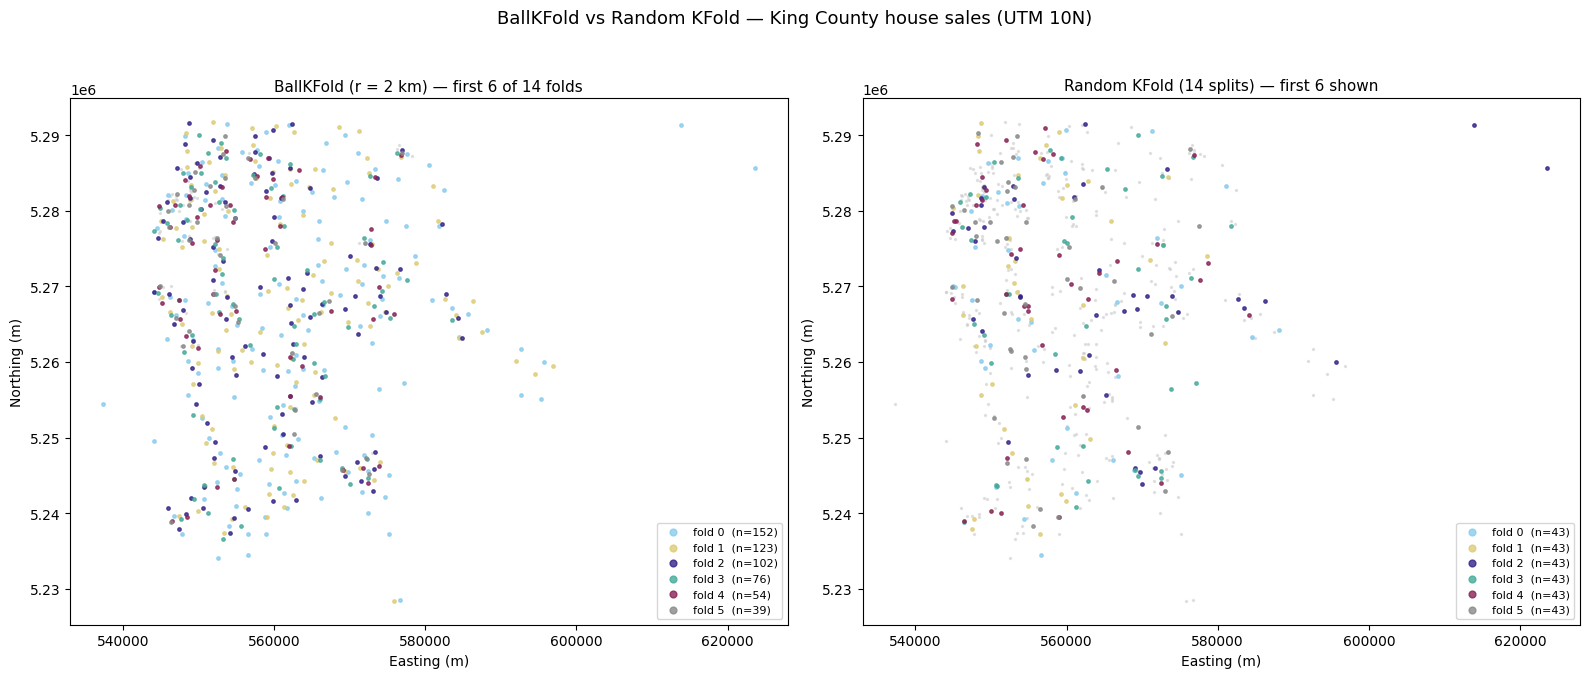

In [5]:
N_SHOW = 6  # only plot first N_SHOW folds for readability

ball_labels = numpy.full(len(gdf), -1, dtype=int)
for fi, (_, test) in enumerate(splits):
    ball_labels[test] = fi

rkf = KFold(n_splits=bkf.n_splits_, shuffle=True, random_state=0)
rand_labels = numpy.full(len(gdf), -1, dtype=int)
for fi, (_, test) in enumerate(rkf.split(coords)):
    rand_labels[test] = fi

gdf["ball_fold"] = ball_labels
gdf["rand_fold"] = rand_labels

# keep only the first N_SHOW colours for the map; grey out the rest
ball_show = numpy.where(ball_labels < N_SHOW, ball_labels, -1)
rand_show = numpy.where(rand_labels < N_SHOW, rand_labels, -1)
gdf["ball_show"] = ball_show
gdf["rand_show"] = rand_show

cmap = colormaps.safe
fold_colors = [cmap(i / max(N_SHOW - 1, 1)) for i in range(N_SHOW)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, title in [
    (axes[0], "ball_show", f"BallKFold (r = 2 km) — first {N_SHOW} of {bkf.n_splits_} folds"),
    (axes[1], "rand_show", f"Random KFold ({bkf.n_splits_} splits) — first {N_SHOW} shown"),
]:
    # grey background: points not in the first N_SHOW folds
    gdf[gdf[col] == -1].plot(ax=ax, color="#ccc", markersize=2, alpha=0.5)
    for fi in range(N_SHOW):
        sub = gdf[gdf[col] == fi]
        sub.plot(ax=ax, color=fold_colors[fi], markersize=6, alpha=0.8,
                 label=f"fold {fi}  (n={len(sub)})")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    ax.legend(fontsize=8, markerscale=2, loc="lower right")

fig.suptitle("BallKFold vs Random KFold — King County house sales (UTM 10N)", fontsize=13)
fig.tight_layout()
plt.show()

## The exclusion guarantee

For every fold, the minimum pairwise distance among test points must be ≥ *r*.
This is a hard structural guarantee from the graph colouring, not a probabilistic one.

In [6]:
r = float(RADIUS_M)
print(f"Exclusion radius: {r/1000:.1f} km\n")
print(f"{'Fold':>5}  {'n_test':>7}  {'min dist (km)':>15}  {'≥ r':>5}")
print("-" * 40)
for fi, (_, test) in enumerate(splits):
    c = coords[test]
    if len(c) == 1:
        print(f"{fi:>5}  {len(test):>7}  {'(singleton)':>15}  {'✓':>5}")
        continue
    D = cdist(c, c)
    numpy.fill_diagonal(D, numpy.inf)
    min_d = D.min()
    ok = "✓" if min_d + 1e-6 >= r else "✗"
    print(f"{fi:>5}  {len(test):>7}  {min_d/1000:>15.3f}  {ok:>5}")

Exclusion radius: 2.0 km

 Fold   n_test    min dist (km)    ≥ r
----------------------------------------
    0      152            2.019      ✓
    1      123            2.002      ✓
    2      102            2.008      ✓
    3       76            2.009      ✓
    4       54            2.018      ✓
    5       39            2.021      ✓
    6       26            2.006      ✓
    7       13            2.038      ✓
    8        5            2.515      ✓
    9        3            2.086      ✓
   10        3            2.003      ✓
   11        2            2.886      ✓
   12        1      (singleton)      ✓
   13        1      (singleton)      ✓


## Cross-validation example

`BallKFold.split()` follows the standard sklearn cross-validator protocol.
We predict log(price) from structural features and compare RMSE per fold
against a random `KFold` with the same number of splits.

In [7]:
feat_cols = ["sqft_liv", "bedrooms", "bathrooms", "grade"]
y = numpy.log(gdf["price"].values)
X = gdf[feat_cols].fillna(0).values

ball_rmse, rand_rmse = [], []
for train, test in splits:
    lr = LinearRegression().fit(X[train], y[train])
    ball_rmse.append(root_mean_squared_error(y[test], lr.predict(X[test])))
for train, test in rkf.split(X, y):
    lr = LinearRegression().fit(X[train], y[train])
    rand_rmse.append(root_mean_squared_error(y[test], lr.predict(X[test])))

print(f"BallKFold  — {len(ball_rmse)} folds, RMSE mean={numpy.mean(ball_rmse):.3f}  std={numpy.std(ball_rmse):.3f}")
print(f"Random KFold — {len(rand_rmse)} folds, RMSE mean={numpy.mean(rand_rmse):.3f}  std={numpy.std(rand_rmse):.3f}")

BallKFold  — 14 folds, RMSE mean=0.364  std=0.081
Random KFold — 14 folds, RMSE mean=0.363  std=0.030


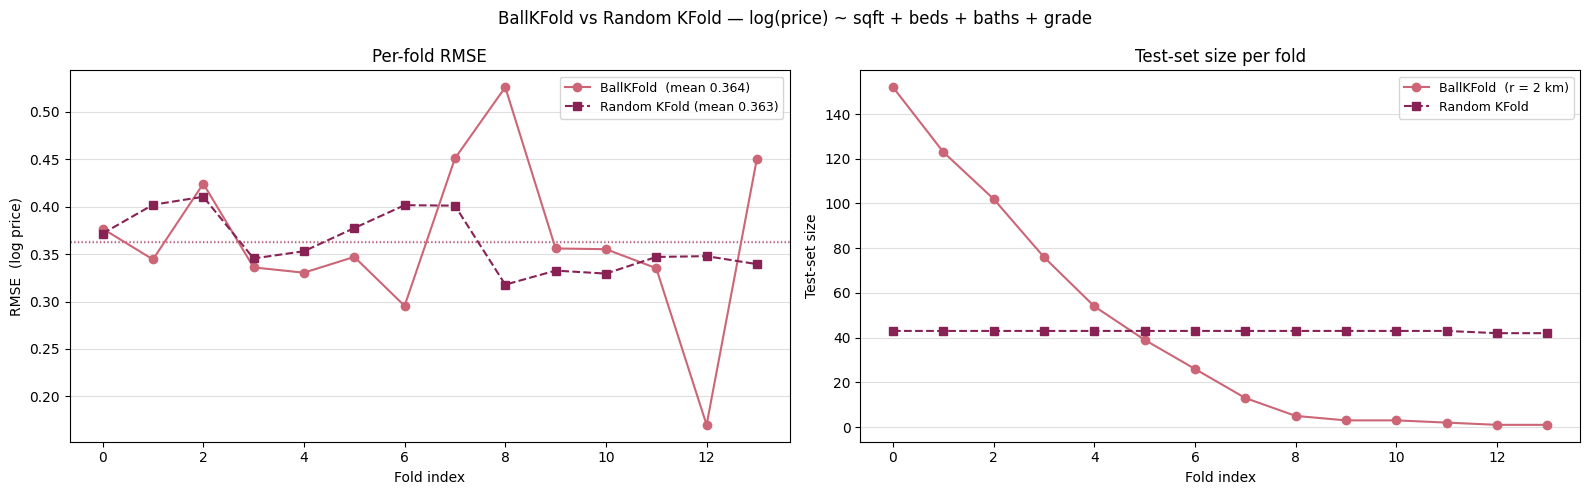

In [8]:
c_ball = colormaps.safe(0.15)
c_rand = colormaps.safe(0.75)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RMSE per fold
ax = axes[0]
ax.plot(ball_rmse, "o-", color=c_ball, label=f"BallKFold  (mean {numpy.mean(ball_rmse):.3f})", zorder=3)
ax.plot(rand_rmse, "s--", color=c_rand, label=f"Random KFold (mean {numpy.mean(rand_rmse):.3f})", zorder=3)
ax.axhline(numpy.mean(ball_rmse), color=c_ball, lw=1, ls=":", alpha=0.7)
ax.axhline(numpy.mean(rand_rmse), color=c_rand, lw=1, ls=":", alpha=0.7)
ax.set_xlabel("Fold index")
ax.set_ylabel("RMSE  (log price)")
ax.set_title("Per-fold RMSE")
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# fold sizes
ax2 = axes[1]
ax2.plot([len(t) for _, t in splits], "o-", color=c_ball,
         label="BallKFold  (r = 2 km)", zorder=3)
ax2.plot([len(t) for _, t in rkf.split(X, y)], "s--", color=c_rand,
         label="Random KFold", zorder=3)
ax2.set_xlabel("Fold index")
ax2.set_ylabel("Test-set size")
ax2.set_title("Test-set size per fold")
ax2.legend(fontsize=9)
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

fig.suptitle("BallKFold vs Random KFold — log(price) ~ sqft + beds + baths + grade", fontsize=12)
fig.tight_layout()
plt.show()